<a href="https://colab.research.google.com/github/irum-zahra-awan/geneai/blob/main/Fridge_to_Recipe_Google_AI_Studio_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="center">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/irum-zahra-awan/geneai/blob/main/Fridge_to_Recipe_Google_AI_Studio_Workshop.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/irum-zahra-awan/geneai/blob/main/Fridge_to_Recipe_Google_AI_Studio_Workshop.ipynb ">
      <br> View on GitHub
    </a>
  </td>
  
</table>

<div style="clear: both;"></div>  



| **Author**|
| --- |
| [**Irum Zahra**](https://github.com/irum-zahra-awan/) |

# Fridge-to-Recipe: A Multimodal AI Assistant with Google AI Studio

**Workshop Level:** Basic → Intermediate  
**Cost:** 100% Free (Gemini API free tier via Google AI Studio)  
**Estimated Time:** 90–120 minutes  
**Prerequisites:** A free Google account, a web browser, and this Colab notebook. No prior AI/ML experience required. Basic Python helps but isn't mandatory.

## What you'll build
An AI assistant that looks at a **photo of your fridge/pantry ingredients** and:
1. Identifies the ingredients it can see,
2. Suggests a recipe using them,
3. Returns that recipe as **clean, structured data** (not just a paragraph) — the same pattern used in real production apps (receipt scanners, ID extractors, inventory tools, etc.)

## What you'll learn
| Part | Topic | Skill |
|---|---|---|
| 0 | Google AI Studio playground | No-code prompt experimentation |
| 1 | API key + Gen AI SDK setup | Environment setup |
| 2 | Text generation | Basic API calls |
| 3 | Multimodal input (image + text) | Vision prompting |
| 4 | Structured (JSON) output | Schemas & reliable data extraction |
| 5 | System instructions & temperature | Prompt/response control |
| 6 (stretch) | Gradio UI | Wrapping AI into a mini app |

> 💡 **Note on cost:** This workshop uses only models and quotas available on the **Gemini API free tier**. You do not need a billing account. Free tier limits are generous for workshop use but do have daily/per-minute caps — see references at the end.

---
## Part 0 — Explore Google AI Studio (No Code, 10 min)

Before writing any code, get familiar with the visual playground where all of this starts.

1. Go to **[https://aistudio.google.com](https://aistudio.google.com)** and sign in with your Google account.
2. Open **Create new → Chat prompt** (or **Stream realtime** to explore later).
3. In the prompt box, try: `Suggest a healthy breakfast using eggs, spinach, and oats.`
4. Explore the **right-hand settings panel**:
   - **Model** dropdown — try `Gemini 2.5 Flash` (fast, free-tier friendly) vs `Gemini 2.5 Pro`.
   - **Temperature** slider — controls randomness/creativity (0 = deterministic, 1+ = more creative).
   - **System instructions** box — sets the assistant's persona/rules.
5. Click the **`</> Get Code`** button above the chat — this is exactly what we'll do manually in Part 1–2, so you can see where the code comes from.
6. Try dragging an **image** into the prompt box and asking a question about it — this is the multimodal capability we'll use in Part 3.

✅ **Checkpoint:** You should now understand that AI Studio = a visual front-end for the same Gemini API we're about to call in Python.

---
## Part 1 — Setup: Get a Free API Key & Install the SDK

### Step 1: Create a free API key
1. Go to **[https://aistudio.google.com/apikey](https://aistudio.google.com/apikey)**
2. Click **Create API key** (choose *Create key in new project* if you don't have one).
3. Copy the key — you'll paste it below. **Never share this key or commit it to a public repo.**

### Step 2: Store it safely in Colab
Use Colab's built-in **Secrets** manager (🔑 icon in the left sidebar) instead of pasting the key directly into a cell:
1. Click the 🔑 key icon in the left sidebar of Colab.
2. Add a new secret named `GOOGLE_API_KEY` and paste your key as the value.
3. Toggle **Notebook access** ON for this secret.

*(If you're not in Colab, the fallback `getpass` prompt below will work too.)*

In [ ]:
# Install the official Google Gen AI Python SDK (unified SDK for Gemini API)
# Docs: https://googleapis.github.io/python-genai/
!pip install -q -U google-genai pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.


In [ ]:
# --- Load the API key ---
import os

try:
    # Preferred path: Colab Secrets (click the key icon in the left sidebar)
    from google.colab import userdata
    api_key = userdata.get('STUDIO_API_KEY')
except Exception:
    api_key = None

if not api_key:
    # Fallback for non-Colab environments (key is hidden while typing, not stored)
    import getpass
    api_key = getpass.getpass('Paste your Google AI Studio API key: ')

os.environ['STUDIO_API_KEY'] = api_key
print('API key loaded ✅' if api_key else 'No API key found ❌')

API key loaded ✅


In [ ]:
# --- Create the Gen AI client ---
# This single client object is how we'll talk to every Gemini model in this workshop.
from google import genai

client = genai.Client(api_key=os.environ['STUDIO_API_KEY'])

# Sanity check: list a couple of available models
print('Connected. Example available models:')
for m in list(client.models.list())[:50]:
    print(' -', m.name)

Connected. Example available models:
 - models/gemini-2.5-flash
 - models/gemini-2.5-pro
 - models/gemini-2.5-flash-preview-tts
 - models/gemini-2.5-pro-preview-tts
 - models/gemini-3.7-flash-video-understanding-eap
 - models/gemma-4-26b-a4b-it
 - models/gemma-4-31b-it
 - models/gemini-flash-latest
 - models/gemini-flash-lite-latest
 - models/gemini-pro-latest
 - models/gemini-2.5-flash-lite
 - models/gemini-2.5-flash-image
 - models/gemini-3-flash-preview
 - models/gemini-3.1-pro-preview
 - models/gemini-3.1-pro-preview-customtools
 - models/gemini-3.1-flash-lite-preview
 - models/gemini-3.1-flash-lite
 - models/gemini-3-pro-image-preview
 - models/gemini-3-pro-image
 - models/nano-banana-pro-preview
 - models/gemini-3.1-flash-image-preview
 - models/gemini-3.1-flash-image
 - models/gemini-3.1-flash-lite-image
 - models/gemini-3.5-flash
 - models/gemini-3.5-flash-lite
 - models/gemini-omni-flash-preview
 - models/gemini-3.6-flash
 - models/gemini-3.7-flash
 - models/lyria-3-clip-previ

---
## Part 2 — Basic: Your First Text Prompt

We'll use **`gemini-3.6-flash`** throughout this workshop — it's fast, capable, and has the most generous **free tier** quota, making it ideal for live workshops.

> 📖 Compare models: [Gemini models overview](https://ai.google.dev/gemini-api/docs/models)

In [ ]:
MODEL = 'gemini-3.6-flash'

response = client.models.generate_content(
    model=MODEL,
    contents='How to write effective prompts. Give me a summary of points to keep in check always'
)

print(response.text)

Writing effective prompts comes down to one core principle: **The quality of the input determines the quality of the output.** AI models do not read minds; they read instructions.

Here is the ultimate checklist of points to keep in check every time you write a prompt, along with a quick formula to structure them.

---

### 🧠 The Core Prompt Formula
Whenever you write a complex prompt, try to include these 5 elements:
> **[Role]** + **[Context]** + **[Task]** + **[Constraints]** + **[Format]**

---

### ✅ Checklist: Points to "Keep in Check Always"

#### 1. Be Specific, Not Vague
*   ❌ *Bad:* "Write an article about fitness."
*   ✅ *Good:* "Write a 500-word article about strength training for beginners over 40."
*   **Check:** Did you state the precise topic, target audience, and intent?

#### 2. Define the Persona or Role
*   Tell the AI *who* it is acting as. This sets the tone, depth, and perspective.
*   *Examples:* "Act as a senior marketing expert," "Explain like a supportive hig

**What just happened?**
- `client.models.generate_content(...)` sends a request to the Gemini API.
- `contents` can be a plain string (as above) for simple text prompts, or a list of mixed content (text + images + files) — which we'll use next.
- `response.text` gives you the model's plain-text answer. The full `response` object also contains metadata like token counts and safety ratings — try `print(response.usage_metadata)`.

---
## Part 3 — Multimodal: Add an Image (Vision Prompting)

Now let's build the core of our Fridge-to-Recipe assistant: sending an **image + text** together.

**Upload any photo of food/ingredients** (or use a sample image URL fallback below if you don't have one handy).

Please upload a photo of ingredients / your fridge or pantry:


Saving pantry_pic.png to pantry_pic.png


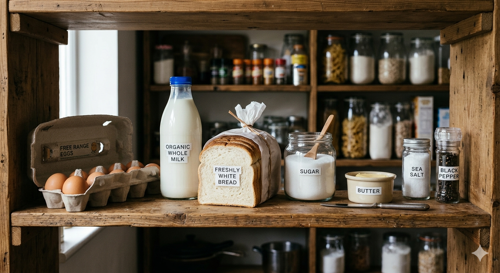

In [ ]:
from PIL import Image
import io

uploaded_image = None

try:
    from google.colab import files
    print('Please upload a photo of ingredients / your fridge or pantry:')
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    uploaded_image = Image.open(io.BytesIO(uploaded[filename]))
except Exception:
    # Fallback sample image (a fridge/pantry shot) if not running in Colab or no file chosen
    import urllib.request
    sample_url = 'https://storage.googleapis.com/generativeai-downloads/images/fridge.jpg'
    print('No upload detected — using a sample image instead.')
    with urllib.request.urlopen(sample_url) as resp:
        uploaded_image = Image.open(io.BytesIO(resp.read()))

uploaded_image.thumbnail((500, 500))  # resize for quick display
uploaded_image

In [ ]:
# Send the IMAGE + a TEXT PROMPT together — this is the core of multimodal prompting.
# `contents` is now a LIST containing both the image object and a text string.

prompt = (
    'Look at this photo of ingredients. '
    'First, list the food items you can identify. '
    'Then suggest ONE simple recipe using mostly those ingredients, '
    'with a short list of steps.'
)

response = client.models.generate_content(
    model=MODEL,
    contents=[uploaded_image, prompt]
)

print(response.text)

Based on the image, here is the list of ingredients and a simple recipe you can make using them.

---

### **Identified Ingredients:**
1. **Eggs** (Free Range)
2. **Whole Milk**
3. **White Bread**
4. **Sugar**
5. **Butter**
6. **Sea Salt**
7. **Black Pepper**

---

### **Recipe Suggestion: Classic French Toast**

Using almost all the main ingredients on the front shelf, you can easily make a quick and delicious **French Toast**.

#### **Steps:**

1. **Whisk the Custard:** In a shallow bowl, whisk together **2 eggs**, **1/4 cup whole milk**, **1 tablespoon sugar**, and a tiny pinch of **sea salt** until fully combined.
2. **Soak the Bread:** Submerge thick slices of the **white bread** into the egg mixture for about 5–10 seconds per side so they soak up the custard without getting too soggy.
3. **Fry:** Heat a knob of **butter** in a skillet over medium heat until melted and bubbly. Place the soaked bread slices in the pan.
4. **Cook & Serve:** Cook for about 2–3 minutes on each side un

🎉 **You've just built a working multimodal AI assistant!**  
Notice how the model reasons over pixels + language together — no separate 'image recognition model' needed.

**Try it yourself:** re-run the cell above after changing the prompt to ask for a *vegetarian* recipe, or a recipe under 20 minutes.

---
## Part 4 — Intermediate: Structured (JSON) Output

Free-text answers are great for chat, but real apps usually need **structured, predictable data** — e.g. to populate a UI, save to a database, or feed another system.

Gemini supports **controlled generation**: you give it a schema, and it returns data matching that schema. We'll define our schema using a **Pydantic model**.

> 📖 Reference: [Structured output / JSON mode guide](https://ai.google.dev/gemini-api/docs/structured-output)

In [ ]:
from pydantic import BaseModel
from typing import List

# Define exactly what shape of data we want back from the model
class Recipe(BaseModel):
    recipe_name: str
    identified_ingredients: List[str]   # what the model saw in the photo
    additional_ingredients_needed: List[str]  # things not in the photo but needed
    steps: List[str]
    estimated_cook_time_minutes: int
    difficulty: str  # e.g. 'Easy', 'Medium', 'Hard'

In [ ]:
from google.genai import types

structured_prompt = (
    'Look at this photo of ingredients and generate a recipe suggestion. '
    'Identify the ingredients you can see, note any common extra ingredients '
    'needed (e.g. salt, oil), and provide clear steps.'
)

response = client.models.generate_content(
    model=MODEL,
    contents=[uploaded_image, structured_prompt],
    config=types.GenerateContentConfig(
        response_mime_type='application/json',   # ask for JSON, not free text
        response_schema=Recipe,                   # enforce our Pydantic schema
    ),
)

# The SDK gives us a ready-to-use parsed Python object matching our schema
recipe: Recipe = response.parsed
recipe

Recipe(recipe_name='Classic French Toast', identified_ingredients=['Eggs', 'Whole Milk', 'White Bread', 'Sugar', 'Butter', 'Sea Salt'], additional_ingredients_needed=['Cinnamon', 'Maple syrup', 'Vanilla extract'], steps=['Whisk the eggs, whole milk, sugar, and a pinch of sea salt together in a shallow bowl until fully blended.', 'Melt a tablespoon of butter in a skillet over medium heat.', 'Dip a slice of white bread into the egg mixture for a few seconds on each side, letting it absorb the liquid.', 'Place the soaked bread onto the hot skillet and cook for 2 to 3 minutes until golden brown.', 'Flip and cook the other side for another 2 to 3 minutes until browned and cooked through.', 'Serve warm with maple syrup, cinnamon, or additional butter.'], estimated_cook_time_minutes=15, difficulty='Easy')

In [ ]:
# Because it's now structured data, we can use it programmatically —
# e.g. pretty-print it, or imagine feeding it straight into a shopping-list app.

print(f"🍽️  {recipe.recipe_name}  ({recipe.difficulty}, ~{recipe.estimated_cook_time_minutes} min)\n")
print('Identified from photo:', ', '.join(recipe.identified_ingredients))
print('You may also need:', ', '.join(recipe.additional_ingredients_needed))
print('\nSteps:')
for i, step in enumerate(recipe.steps, 1):
    print(f'  {i}. {step}')

🍽️  Classic French Toast  (Easy, ~15 min)

Identified from photo: Eggs, Whole Milk, White Bread, Sugar, Butter, Sea Salt
You may also need: Cinnamon, Maple syrup, Vanilla extract

Steps:
  1. Whisk the eggs, whole milk, sugar, and a pinch of sea salt together in a shallow bowl until fully blended.
  2. Melt a tablespoon of butter in a skillet over medium heat.
  3. Dip a slice of white bread into the egg mixture for a few seconds on each side, letting it absorb the liquid.
  4. Place the soaked bread onto the hot skillet and cook for 2 to 3 minutes until golden brown.
  5. Flip and cook the other side for another 2 to 3 minutes until browned and cooked through.
  6. Serve warm with maple syrup, cinnamon, or additional butter.


**Why this matters:** This exact pattern — *image/text in → validated structured data out* — is how you'd build receipt scanners, form parsers, inventory checkers, and more, all on top of the same free-tier model.

---
## Part 5 — Controlling the Model: System Instructions & Temperature

Two of the most useful controls for tuning behavior:
- **`system_instruction`** — sets persistent rules/persona for the model (like a job description).
- **`temperature`** — 0.0 = focused/deterministic, higher (e.g. 1.0+) = more creative/varied.

Let's compare a strict, low-temperature 'nutritionist' vs. a playful, high-temperature 'chef'.

In [ ]:
personas = {
    'Strict Nutritionist (temp=0.1)': dict(
        system_instruction='You are a strict clinical nutritionist. Be concise, factual, and health-focused. No jokes.',
        temperature=0.1,
    ),
    'Playful Chef (temp=1.2)': dict(
        system_instruction='You are an enthusiastic, funny TV chef. Use vivid, playful language.',
        temperature=1.2,
    ),
}

for label, cfg in personas.items():
    resp = client.models.generate_content(
        model=MODEL,
        contents=[uploaded_image, 'Suggest a recipe using these ingredients, in 3-4 sentences.'],
        config=types.GenerateContentConfig(
            system_instruction=cfg['system_instruction'],
            temperature=cfg['temperature'],
        ),
    )
    print(f'--- {label} ---')
    print(resp.text)
    print()

--- Strict Nutritionist (temp=0.1) ---
Whisk two free-range eggs with two tablespoons of organic whole milk, a pinch of sea salt, and black pepper to form a protein-dense mixture. Lightly dip two slices of bread into the mixture until evenly coated, avoiding excessive soaking. Melt a minimal quantity of butter in a skillet over medium heat and cook the bread for two to three minutes per side until the egg is fully cooked and golden. This savory French toast provides high-quality amino acids and essential micronutrients, though substituting whole-grain bread in future meals is recommended to increase dietary fiber.

--- Playful Chef (temp=1.2) ---
Welcome to flavor town, my lovely foodies, because with this glorious lineup, we are making the ultimate, sizzlin' **Golden French Toast**! 

Whisk those beautiful eggs with a splash of milk, a sweet kiss of sugar, and a cheeky pinch of sea salt to create a velvety custard bath fit for bread royalty. 

Dunk those fluffy white slices deep into 

**Try it:** change the `system_instruction` strings above (e.g. 'You are a budget college student cooking with 3 ingredients') and re-run to see how much control you have over tone and content using the same underlying model and image.

---
## Part 6 (Stretch Goal) — Wrap It in a Mini Web App with Gradio

Let's turn everything above into an interactive demo anyone can use, right inside Colab.

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

def fridge_to_recipe(image: Image.Image):
    """Takes a PIL image, returns a formatted recipe string using our structured pipeline."""
    if image is None:
        return 'Please upload an image first.'

    resp = client.models.generate_content(
        model=MODEL,
        contents=[image, structured_prompt],
        config=types.GenerateContentConfig(
            response_mime_type='application/json',
            response_schema=Recipe,
        ),
    )
    r: Recipe = resp.parsed

    steps_md = '\n'.join(f'{i}. {s}' for i, s in enumerate(r.steps, 1))
    return (
        f"## {r.recipe_name}\n"
        f"**Difficulty:** {r.difficulty}  |  **Time:** ~{r.estimated_cook_time_minutes} min\n\n"
        f"**Identified ingredients:** {', '.join(r.identified_ingredients)}\n\n"
        f"**You may also need:** {', '.join(r.additional_ingredients_needed)}\n\n"
        f"**Steps:**\n{steps_md}"
    )

demo = gr.Interface(
    fn=fridge_to_recipe,
    inputs=gr.Image(type='pil', label='Upload a fridge/pantry photo'),
    outputs=gr.Markdown(label='Suggested Recipe'),
    title='Fridge-to-Recipe AI Assistant',
    description='Powered by the Gemini API (free tier) via Google AI Studio.',
)

demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://61e14887ad82ca9dc1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Wrap-Up & Practice Exercises

**You covered:** the AI Studio playground → API key setup → text generation → multimodal (image) prompting → structured JSON output → system instructions/temperature → a deployable Gradio demo — all on the free tier.

### Try these on your own
1. **Basic:** Change the prompt to identify *cuisines* (Italian, Thai, etc.) that fit the ingredients.
2. **Intermediate:** Extend the `Recipe` schema with a `dietary_tags: List[str]` field (e.g. `['vegan', 'gluten-free']`) and have the model fill it in.
3. **Intermediate:** Add a second image input (e.g. two photos: fridge + pantry) and combine them in one `contents` list.
4. **Advanced (preview for later workshops):** Explore [Google AI Studio's Function Calling](https://ai.google.dev/gemini-api/docs/function-calling) to let the model call a real 'search recipe database' tool instead of inventing one.

---
## 📚 References & Further Reading
- Google AI Studio: https://aistudio.google.com
- Get an API key: https://aistudio.google.com/apikey
- Gemini API docs (overview): https://ai.google.dev/gemini-api/docs
- Gemini models & capabilities: https://ai.google.dev/gemini-api/docs/models
- Google Gen AI Python SDK (`google-genai`) reference: https://googleapis.github.io/python-genai/
- Image/vision understanding guide: https://ai.google.dev/gemini-api/docs/image-understanding
- Structured output / JSON mode guide: https://ai.google.dev/gemini-api/docs/structured-output
- System instructions & configuration: https://ai.google.dev/gemini-api/docs/text-generation
- Free tier rate limits & pricing: https://ai.google.dev/gemini-api/docs/rate-limits
- Gradio documentation: https://www.gradio.app/docs

*Workshop material prepared for internal training use. Always check the links above for the most current model names, limits, and pricing, as these evolve frequently.*